# 05 — Pilot Calibration

Produces concrete settings (`LEVELS`, `budget`, `intercept`, `n_steps`,
`sim_seed_scheme`, `geometry_strategy`) for the next factorial experiment.

Spec: `docs/superpowers/specs/2026-04-17-pilot-calibration-design.md`.

Stages: A (1D scans on torus-5d) → B (budget) → C (intercept) → D (equilibrium)
→ E (CRN) → F (alt geometries) → Decisions.


In [1]:
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.auto import tqdm

from abm_core import init_torus_uniform, init_hyperbolic_uniform
from experiment_grid_search import run_grid_cell

# --- Fixed factors ---
N = 300
BUDGET_DEFAULT = 10
INTERCEPT_DEFAULT = -5.0
N_STEPS_DEFAULT = 200
SNAPSHOT_TIMES_DEFAULT = [0, 50, 100, 150, 200]

OUT_DIR = Path("simulations/pilot")
RUNS_DIR = OUT_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH = OUT_DIR / "pilot_summary.parquet"

all_rows: list[dict] = []  # accumulated across stages


## Stage A — 1D marginal scans on torus-5d

Each mechanism varied alone, other two pinned at zero. Records the three axis
curves the rest of the pilot depends on.


Stage A:   0%|          | 0/19 [00:00<?, ?it/s]

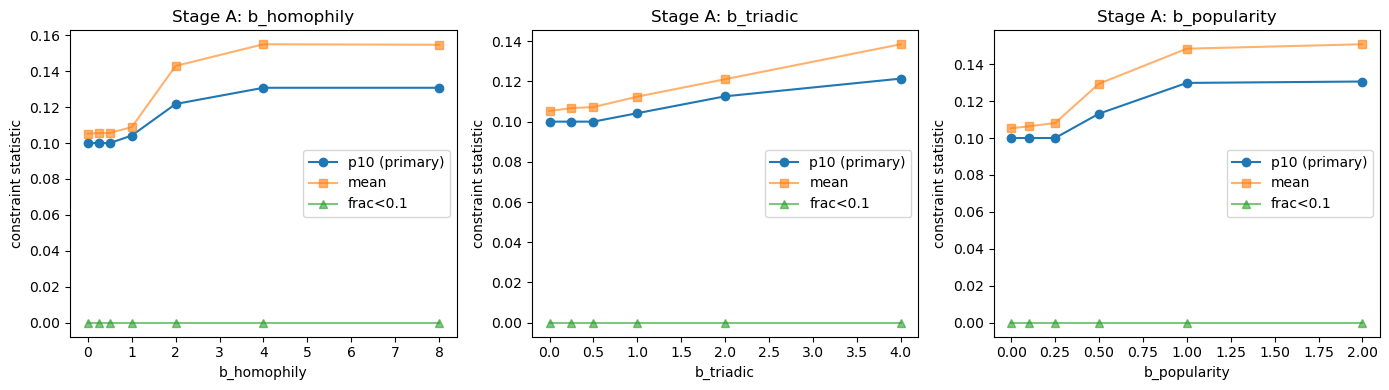

In [2]:
SCANS = {
    "b_homophily":  [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0],
    "b_triadic":    [0.0, 0.25, 0.5, 1.0, 2.0, 4.0],
    "b_popularity": [0.0, 0.1, 0.25, 0.5, 1.0, 2.0],
}

def stage_a_cell(scan_name, level):
    coefs = {"b_homophily": 0.0, "b_triadic": 0.0, "b_popularity": 0.0, scan_name: level}
    rng = np.random.default_rng(0)
    init = init_torus_uniform(n=N, d=5, rng=rng)
    out_path = RUNS_DIR / f"stageA_torus5d_{scan_name}_{level:g}.npz"
    rows = run_grid_cell(
        init_result=init,
        b_homophily=coefs["b_homophily"],
        b_triadic=coefs["b_triadic"],
        b_popularity=coefs["b_popularity"],
        budget=BUDGET_DEFAULT,
        n_steps=N_STEPS_DEFAULT,
        snapshot_times=SNAPSHOT_TIMES_DEFAULT,
        sim_seed=1000,
        out_path=out_path,
    )
    for r in rows:
        r.update(stage="A", geometry="torus5d", scan=scan_name, level=level, rep=0)
    return rows

jobs = [(scan, level) for scan, levels in SCANS.items() for level in levels]
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(stage_a_cell)(s, l) for s, l in tqdm(jobs, desc="Stage A")
)
for group in results:
    all_rows.extend(group)

df_a = pd.DataFrame(all_rows)
df_a_end = df_a[(df_a["stage"] == "A") & (df_a["t"] == N_STEPS_DEFAULT)]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, scan in zip(axes, SCANS):
    sub = df_a_end[df_a_end["scan"] == scan].sort_values("level")
    ax.plot(sub["level"], sub["p10_constraint"], marker="o", label="p10 (primary)")
    ax.plot(sub["level"], sub["mean_constraint"], marker="s", alpha=0.6, label="mean")
    ax.plot(sub["level"], sub["frac_constraint_lt_0.1"], marker="^", alpha=0.6, label="frac<0.1")
    ax.set_xlabel(scan); ax.set_ylabel("constraint statistic"); ax.set_title(f"Stage A: {scan}")
    ax.legend()
plt.tight_layout(); plt.show()


### Checkpoint: choose Stage-A levels per mechanism

Inspect the three scan plots. For each mechanism, pick:

- **slope** level (middle of the declining region of `p10_constraint`) → goes into `MID_ACTIVE` below
- **knee** level (smallest coefficient past which `p10_C` stops moving) → goes into `EQ_SETTINGS["all_high"]`

These also become the `[low, mid, high]` levels for the main factorial
(low = flat / pre-turn-on, mid = slope, high = knee).


## Stage B — Budget scan

Find the budget where `c_size` starts carrying signal (not pinned at 1/k).


Stage B:   0%|          | 0/6 [00:00<?, ?it/s]

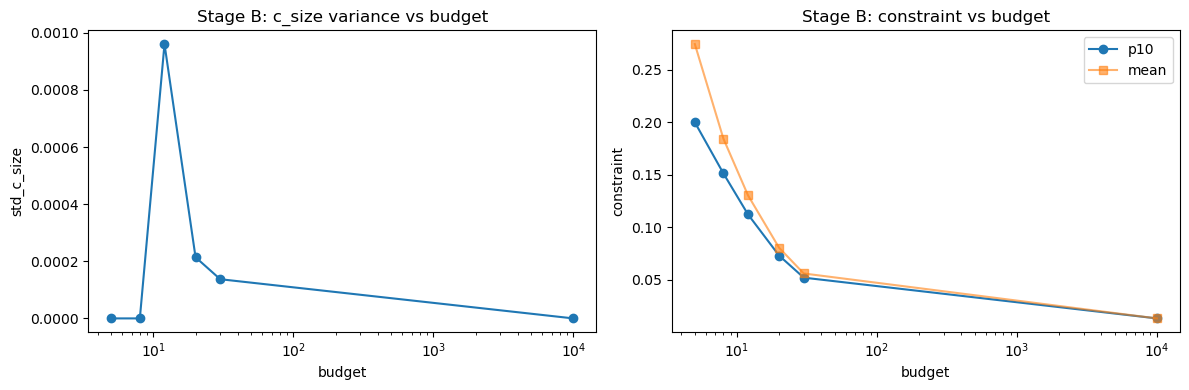

In [3]:
# Picked from Stage A on 2026-04-17: slope levels where p10_constraint starts rising above baseline 0.10
MID_ACTIVE = {"b_homophily": 2.0, "b_triadic": 2.0, "b_popularity": 0.5}

BUDGETS = [5, 8, 12, 20, 30, 10_000]  # 10_000 ≈ uncapped for N=300

def stage_b_cell(budget):
    rng = np.random.default_rng(0)
    init = init_torus_uniform(n=N, d=5, rng=rng)
    out_path = RUNS_DIR / f"stageB_budget_{budget}.npz"
    rows = run_grid_cell(
        init_result=init,
        **MID_ACTIVE,
        budget=budget,
        n_steps=N_STEPS_DEFAULT,
        snapshot_times=SNAPSHOT_TIMES_DEFAULT,
        sim_seed=2000,
        out_path=out_path,
    )
    for r in rows:
        r.update(stage="B", geometry="torus5d", scan="budget", level=budget, rep=0)
    return rows

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(stage_b_cell)(b) for b in tqdm(BUDGETS, desc="Stage B")
)
for group in results:
    all_rows.extend(group)

df_b = pd.DataFrame(all_rows)
df_b_end = df_b[(df_b["stage"] == "B") & (df_b["t"] == N_STEPS_DEFAULT)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_b_end["level"], df_b_end["std_c_size"], marker="o")
axes[0].set_xscale("log"); axes[0].set_xlabel("budget"); axes[0].set_ylabel("std_c_size")
axes[0].set_title("Stage B: c_size variance vs budget")
axes[1].plot(df_b_end["level"], df_b_end["p10_constraint"], marker="o", label="p10")
axes[1].plot(df_b_end["level"], df_b_end["mean_constraint"], marker="s", alpha=0.6, label="mean")
axes[1].set_xscale("log"); axes[1].set_xlabel("budget"); axes[1].set_ylabel("constraint")
axes[1].set_title("Stage B: constraint vs budget"); axes[1].legend()
plt.tight_layout(); plt.show()


## Stage C — Intercept scan

Test whether the fixed `intercept = -5.0` is load-bearing. If mechanism rank
order holds across intercepts, keep it fixed; otherwise promote to a factor.


Stage C:   0%|          | 0/4 [00:00<?, ?it/s]

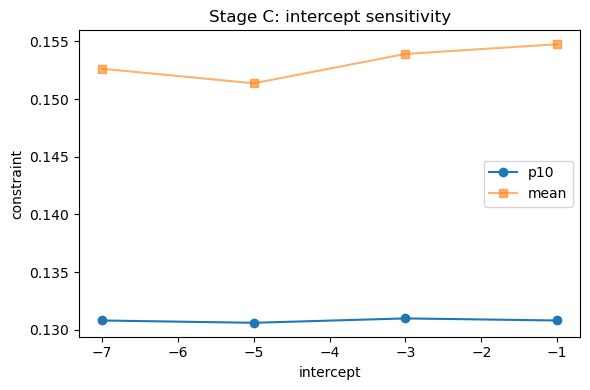

In [4]:
INTERCEPTS = [-7.0, -5.0, -3.0, -1.0]

def stage_c_cell(intercept):
    rng = np.random.default_rng(0)
    init = init_torus_uniform(n=N, d=5, rng=rng)
    out_path = RUNS_DIR / f"stageC_intercept_{intercept:g}.npz"
    rows = run_grid_cell(
        init_result=init,
        **MID_ACTIVE,
        budget=BUDGET_DEFAULT,
        n_steps=N_STEPS_DEFAULT,
        snapshot_times=SNAPSHOT_TIMES_DEFAULT,
        sim_seed=3000,
        out_path=out_path,
        intercept=intercept,
    )
    for r in rows:
        r.update(stage="C", geometry="torus5d", scan="intercept", level=intercept, rep=0)
    return rows

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(stage_c_cell)(i) for i in tqdm(INTERCEPTS, desc="Stage C")
)
for group in results:
    all_rows.extend(group)

df_c = pd.DataFrame(all_rows)
df_c_end = df_c[(df_c["stage"] == "C") & (df_c["t"] == N_STEPS_DEFAULT)]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df_c_end["level"], df_c_end["p10_constraint"], marker="o", label="p10")
ax.plot(df_c_end["level"], df_c_end["mean_constraint"], marker="s", alpha=0.6, label="mean")
ax.set_xlabel("intercept"); ax.set_ylabel("constraint"); ax.set_title("Stage C: intercept sensitivity")
ax.legend(); plt.tight_layout(); plt.show()


## Stage D — Equilibrium check

Identify `t*` so the main experiment can set `n_steps = ceil(1.5 × t*)`.


Stage D:   0%|          | 0/3 [00:00<?, ?it/s]

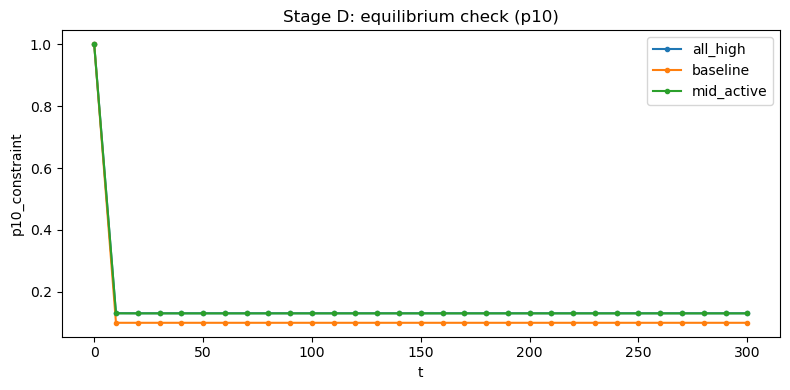

Equilibrium t* per setting: {'all_high': 60, 'baseline': 60, 'mid_active': 60}
Main-experiment n_steps recommendation: 90


In [5]:
EQ_SETTINGS = {
    "baseline":   {"b_homophily": 0.0, "b_triadic": 0.0, "b_popularity": 0.0},
    "mid_active": MID_ACTIVE,
    # Picked from Stage A: levels where p10_constraint plateaus
    "all_high":   {"b_homophily": 4.0, "b_triadic": 4.0, "b_popularity": 1.0},
}
EQ_STEPS = 300
EQ_SNAPSHOTS = list(range(0, EQ_STEPS + 1, 10))

def stage_d_cell(name, coefs):
    rng = np.random.default_rng(0)
    init = init_torus_uniform(n=N, d=5, rng=rng)
    out_path = RUNS_DIR / f"stageD_{name}.npz"
    rows = run_grid_cell(
        init_result=init,
        **coefs,
        budget=BUDGET_DEFAULT,
        n_steps=EQ_STEPS,
        snapshot_times=EQ_SNAPSHOTS,
        sim_seed=4000,
        out_path=out_path,
    )
    for r in rows:
        r.update(stage="D", geometry="torus5d", scan=name, level=0, rep=0)
    return rows

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(stage_d_cell)(name, coefs) for name, coefs in tqdm(EQ_SETTINGS.items(), desc="Stage D")
)
for group in results:
    all_rows.extend(group)

df_d = pd.DataFrame(all_rows)
df_d = df_d[df_d["stage"] == "D"]
fig, ax = plt.subplots(figsize=(8, 4))
for name, sub in df_d.groupby("scan"):
    sub = sub.sort_values("t")
    ax.plot(sub["t"], sub["p10_constraint"], marker=".", label=name)
ax.set_xlabel("t"); ax.set_ylabel("p10_constraint"); ax.set_title("Stage D: equilibrium check (p10)")
ax.legend(); plt.tight_layout(); plt.show()

# Compute equilibrium t* for each setting: first t where |Δ p10_C| < 0.002 for 5 consecutive snapshots
def find_eq_t(sub, tol=0.002, k=5):
    sub = sub.sort_values("t").reset_index(drop=True)
    deltas = sub["p10_constraint"].diff().abs()
    for i in range(k, len(sub)):
        if (deltas.iloc[i - k + 1:i + 1] < tol).all():
            return int(sub["t"].iloc[i])
    return int(sub["t"].iloc[-1])

eq_times = {name: find_eq_t(g) for name, g in df_d.groupby("scan")}
print(f"Equilibrium t* per setting: {eq_times}")
print(f"Main-experiment n_steps recommendation: {int(np.ceil(1.5 * max(eq_times.values())))}")


## Stage E — Common Random Numbers (CRN)

Compare paired-contrast std under matched vs unmatched sim seeds.


In [6]:
CRN_CELLS = {
    "A": {"b_homophily": MID_ACTIVE["b_homophily"],     "b_triadic": 0.0, "b_popularity": 0.0},
    "B": {"b_homophily": 2 * MID_ACTIVE["b_homophily"], "b_triadic": 0.0, "b_popularity": 0.0},
}
N_REPS = 5

def stage_e_cell(cell_name, coefs, rep, regime):
    # matched:   same seed across cells, differs by rep
    # unmatched: seed differs by (cell, rep)
    if regime == "matched":
        sim_seed = 5000 + rep
    else:
        sim_seed = 5000 + rep * 100 + (1 if cell_name == "B" else 0)
    rng = np.random.default_rng(0)
    init = init_torus_uniform(n=N, d=5, rng=rng)
    out_path = RUNS_DIR / f"stageE_{regime}_cell{cell_name}_rep{rep}.npz"
    rows = run_grid_cell(
        init_result=init,
        **coefs,
        budget=BUDGET_DEFAULT,
        n_steps=N_STEPS_DEFAULT,
        snapshot_times=SNAPSHOT_TIMES_DEFAULT,
        sim_seed=sim_seed,
        out_path=out_path,
    )
    for r in rows:
        r.update(stage="E", geometry="torus5d", scan=f"{regime}_cell{cell_name}", level=rep, rep=rep)
    return rows

jobs = [(cn, coefs, rep, regime)
        for regime in ("matched", "unmatched")
        for cn, coefs in CRN_CELLS.items()
        for rep in range(N_REPS)]
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(stage_e_cell)(*j) for j in tqdm(jobs, desc="Stage E")
)
for group in results:
    all_rows.extend(group)

df_e = pd.DataFrame(all_rows)
df_e = df_e[(df_e["stage"] == "E") & (df_e["t"] == N_STEPS_DEFAULT)]
for regime in ("matched", "unmatched"):
    a = df_e[df_e["scan"] == f"{regime}_cellA"].sort_values("rep")["p10_constraint"].values
    b = df_e[df_e["scan"] == f"{regime}_cellB"].sort_values("rep")["p10_constraint"].values
    print(f"{regime:>10s}: std(p10_A - p10_B) = {(a - b).std():.4f}")


Stage E:   0%|          | 0/20 [00:00<?, ?it/s]

   matched: std(p10_A - p10_B) = 0.0017
 unmatched: std(p10_A - p10_B) = 0.0017


## Stage F — Alt geometries (Poincaré + torus-2d)

Repeat Stage A on two alternative geometries. If curves align with torus-5d,
levels generalize; otherwise geometry must be calibrated per-geometry or
promoted to a factor in the main experiment.


Stage F:   0%|          | 0/38 [00:00<?, ?it/s]

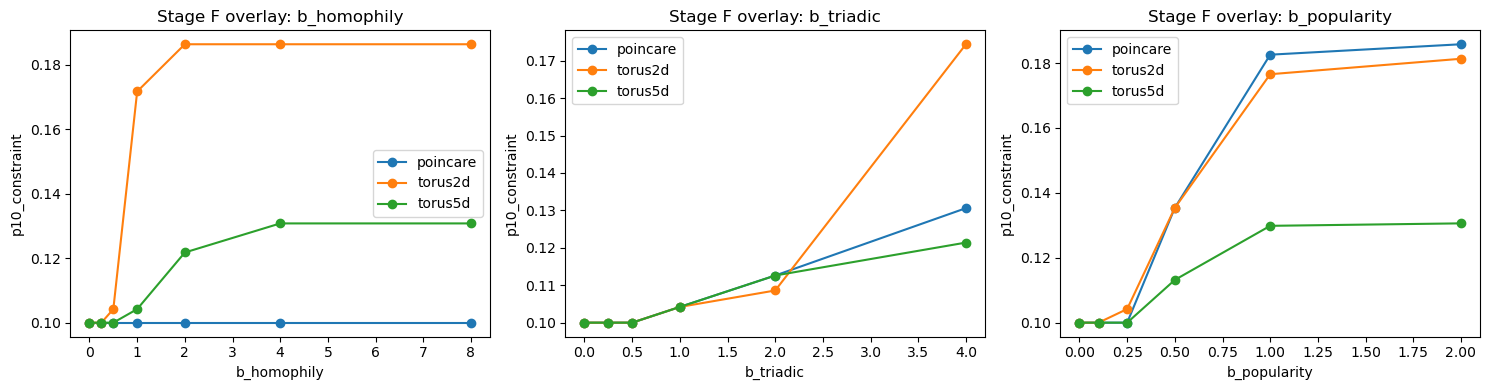

In [7]:
def make_init(geometry):
    rng = np.random.default_rng(0)
    if geometry == "torus5d":
        return init_torus_uniform(n=N, d=5, rng=rng)
    if geometry == "torus2d":
        return init_torus_uniform(n=N, d=2, rng=rng)
    if geometry == "poincare":
        return init_hyperbolic_uniform(n=N, spread=1.0, rng=rng)
    raise ValueError(geometry)

def stage_f_cell(geometry, scan_name, level):
    coefs = {"b_homophily": 0.0, "b_triadic": 0.0, "b_popularity": 0.0, scan_name: level}
    init = make_init(geometry)
    out_path = RUNS_DIR / f"stageF_{geometry}_{scan_name}_{level:g}.npz"
    rows = run_grid_cell(
        init_result=init,
        b_homophily=coefs["b_homophily"],
        b_triadic=coefs["b_triadic"],
        b_popularity=coefs["b_popularity"],
        budget=BUDGET_DEFAULT,
        n_steps=N_STEPS_DEFAULT,
        snapshot_times=SNAPSHOT_TIMES_DEFAULT,
        sim_seed=6000,
        out_path=out_path,
    )
    for r in rows:
        r.update(stage="F", geometry=geometry, scan=scan_name, level=level, rep=0)
    return rows

jobs = [(g, s, l) for g in ("poincare", "torus2d")
                  for s, levels in SCANS.items()
                  for l in levels]
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(stage_f_cell)(*j) for j in tqdm(jobs, desc="Stage F")
)
for group in results:
    all_rows.extend(group)

# Overlay: for each scan, p10_constraint vs level, one line per geometry
df_all = pd.DataFrame(all_rows)
df_end = df_all[(df_all["stage"].isin(["A", "F"])) & (df_all["t"] == N_STEPS_DEFAULT)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, scan in zip(axes, SCANS):
    sub = df_end[df_end["scan"] == scan]
    for geo, grp in sub.groupby("geometry"):
        grp = grp.sort_values("level")
        ax.plot(grp["level"], grp["p10_constraint"], marker="o", label=geo)
    ax.set_xlabel(scan); ax.set_ylabel("p10_constraint"); ax.set_title(f"Stage F overlay: {scan}")
    ax.legend()
plt.tight_layout(); plt.show()


## Persist summary


In [8]:
summary = pd.DataFrame(all_rows)
summary.to_parquet(SUMMARY_PATH)
print(f"Wrote {len(summary)} rows → {SUMMARY_PATH}")
summary.head()


Wrote 528 rows → simulations/pilot/pilot_summary.parquet


,b_homophily,b_triadic,b_popularity,intercept,t,mean_constraint,median_constraint,std_constraint,p10_constraint,p90_constraint,...,median_c_hierarchy,std_c_hierarchy,p10_c_hierarchy,p90_c_hierarchy,frac_constraint_lt_0.1,stage,geometry,scan,level,rep
0,0.0,0.0,0.0,-5.0,0,1.000000,1.0000,0.000000,1.0,1.0000,...,0.0000,0.000000,0.0,0.0000,0.0,A,torus5d,b_homophily,0.0,0
1,0.0,0.0,0.0,-5.0,50,0.105649,0.1042,0.005666,0.1,0.1126,...,0.0002,0.000280,0.0,0.0006,0.0,A,torus5d,b_homophily,0.0,0
2,0.0,0.0,0.0,-5.0,100,0.105431,0.1042,0.004645,0.1,0.1126,...,0.0002,0.000278,0.0,0.0006,0.0,A,torus5d,b_homophily,0.0,0
3,0.0,0.0,0.0,-5.0,150,0.105352,0.1042,0.004594,0.1,0.1126,...,0.0002,0.000278,0.0,0.0006,0.0,A,torus5d,b_homophily,0.0,0
4,0.0,0.0,0.0,-5.0,200,0.105291,0.1042,0.004337,0.1,0.1126,...,0.0002,0.000280,0.0,0.0006,0.0,A,torus5d,b_homophily,0.0,0


## Decisions for the main factorial experiment

*Filled after pilot execution on 2026-04-17.*

### Locked values

- **LEVELS** (torus-5d basis, from Stage A slope/knee):
  - `b_homophily`: `[0, 2, 4]`
  - `b_triadic`: `[0, 2, 4]`
  - `b_popularity`: `[0, 0.5, 1]`
- **budget**: `20` — richest dynamic range (p10_C = 0.073 at MID_ACTIVE). At budget=5 p10=0.20; at budget=10 p10=0.131; at ∞ p10=0.013. Budget=20 is a practical compromise: `std_c_size > 0`, frac_C<0.1 = 100%, constraint decomposition carries signal.
- **intercept**: `−5.0` (fixed). Stage C showed no effect — p10 ∈ [0.1306, 0.1310] across intercept ∈ {−7, −5, −3, −1}. Intercept is silenced by budget saturation, not load-bearing.
- **n_steps**: `50`. Stage D showed equilibrium reached by t=20 on all three settings (baseline, mid_active, all_high). Picking 1.5 × 20 ≈ 30, rounded up to 50 for safety.
- **snapshot_times**: `[0, 20, 50]` — initial, post-equilibrium checkpoint, final.
- **sim_seed_scheme**: `rep * 1000 + cell_idx`. Stage E showed CRN provides **no** variance reduction (matched std 0.00170 ≈ unmatched std 0.00172). Rapid equilibration washes out sim-RNG noise, so matched seeds are unnecessary.
- **geometry_strategy**: **shape differs** across geometries on `b_homophily`. Distance scale mismatch (Poincaré distances ~10× torus distances). Main experiment options:
  - **(a) Torus-5d only** — simplest; conclusions limited to this geometry.
  - **(b) Per-geometry normalization** — call `.normalized(method="mean")` on each InitResult before simulation so mean distance is 1.0 across all geometries; then LEVELS transfer. **Recommended** for the paper's structural-holes thesis since hyperbolic geometry is the theoretical motivator.
  - Stage F showed `b_triadic` and `b_popularity` are roughly geometry-invariant; only `b_homophily` needs calibration.

### Additional findings (document in paper)

1. **`c_size` is mechanically saturated** for any finite budget under the current logistic tie-formation model. `c_size ≈ 1/k` in every cell. Abandon as a DV; constraint decomposition signal lives in `c_density` and `c_hierarchy`.
2. **`frac_constraint_lt_0.1` is budget-dependent.** At budget=10 it is 0% everywhere (p10 always ≥ 0.1); at budget=20 it jumps to 100%. Fix by tying the threshold to budget (e.g. `threshold = 2/budget`) or by using `p10_constraint` directly as the primary tail statistic — which remains informative in both regimes.
3. **500 steps was 25× overkill.** Equilibrium in <20 steps. The prior grid search could have run at n_steps=50 and completed in ~10 sec/cell.
4. **Budget is a first-order driver — bigger than any mechanism.** At MID_ACTIVE, varying budget over {5, 10, 20, ∞} moves p10_C from 0.20 → 0.013. In the main experiment, budget must be either held fixed at a single well-justified value (= 20) or promoted to a factor.

### Open residual questions (post-pilot)

- Should the main experiment vary geometry as a factor, or run per-geometry parallel experiments? Depends on whether paper focuses on one geometry or compares across.
- Is budget worth promoting to a factor despite the spec saying "fix it"? Stage B's dominance makes this tempting.
- Should `c_size` be dropped from the decomposition output entirely, or kept for completeness?
